--- Primeras filas de datos con ruido Uniforme ---
          X         Y         Z
0 -0.434593 -1.152057  0.069464
1  1.561274  1.342278  2.645059
2  0.803627  2.450052  4.635104
3  0.341753 -0.474035 -1.759513
4 -1.191551 -1.009013 -2.174539


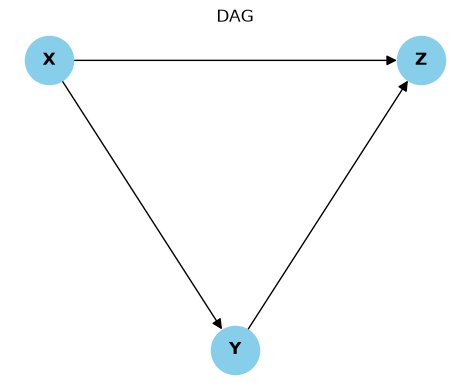

In [11]:
# ==============================================================================
# BLOQUE 1: GENERACIÓN DE DATOS SINTÉTICOS PARA EL TRIÁNGULO NO LINEAL
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import time
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed

# 1. Definición del Grafo (X -> Y -> Z y X -> Z)
graph_triangle = nx.DiGraph([
    ('X', 'Y'),
    ('X', 'Z'),
    ('Y', 'Z')
])
# 2. Generación del SCM No Lineal Verdadero con RUIDO UNIFORME
def generate_synthetic_triangle_data_uniform(num_samples=2000, seed=42):
    np.random.seed(seed)
    
    # Definimos los límites para que la varianza sea 1.0
    # Varianza de una uniforme = (high - low)^2 / 12. 
    # Para varianza = 1, (high - low) debe ser sqrt(12) ≈ 3.464
    # Usamos [-1.732, 1.732]
    low, high = -1.732, 1.732
    
    # RUIDO UNIFORME
    eps_X = np.random.uniform(low, high, num_samples)
    eps_Y = np.random.uniform(low, high, num_samples)
    eps_Z = np.random.uniform(low, high, num_samples)
    
    # Ecuaciones del SCM (Se mantienen igual)
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

# Crear el DataFrame con ruido uniforme
data_triangle = generate_synthetic_triangle_data_uniform(num_samples=2000)

print("--- Primeras filas de datos con ruido Uniforme ---")
print(data_triangle.head())

# 3. Partición de datos (50% Train / 50% Eval) y Normalización
factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)

# Mapeo de tipos requerido por la arquitectura kan_model_mixed
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {} # Todo es puramente continuo

# Pintar el grafo estructural 
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG")
plt.show()

In [12]:
# ==============================================================================
# BLOQUE 2: ENTRENAMIENTO MULTI-ESTRATEGIA EXCLUSIVO CON DATOS DE TRAIN
# ==============================================================================

# 1. Generación de la rejilla de pesos (11 puntos entre 0.0 y 1.0)
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)

# Hiperparámetros base globales de la red KAN
base_kan_params = {
    'hidden_dim': 5,
    'batch_size': -1,     # Batch completo para estabilizar estimaciones del HSIC conjunto
    'grid': 5,
    'k': 5,
    'seed': 42,
    'lr': 0.002,
    'early_stop': True,
    'steps': 5000,
    'lamb': 0.05,
    'lamb_entropy': 0.05,
    'sparse_init': False,
    'mult_kan': True,
    'try_gpu': False,
    'verbose': 0
}

# Estructuras de datos para almacenar los resultados en la memoria RAM
baselines = ['mse', 'hsic']
trained_models = {}
times_log = {}

# Función auxiliar para empaquetar la configuración anidada por nodo que exige kan_model_mixed
def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta):
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

# --- PARTE A: ENTRENAMIENTO DE LÍNEAS BASE PURAS ---
for strategy in baselines:
    print(f"Entrenando KAN Estrategia Pura: {strategy.upper()}...")
    alpha_val, beta_val = (1.0, 0.0) if strategy == "mse" else (0.0, 1.0)
    
    params_estructurados = crear_estructura_nodos(
        graph_triangle, base_kan_params, strategy, alpha_val, beta_val
    )
    
    model = kan_model_mixed(graph_triangle, params_estructurados)
    
    t_start = time.time()
    # VALIDACIÓN: Entrenamos únicamente con el conjunto de TRAIN
    # El modelo calculará internamente el HSIC conjunto usando /models/kan.py
    model.fit(data=factual_train_d)
    elapsed = time.time() - t_start
    
    # Guardado en memoria
    trained_models[strategy] = model
    times_log[strategy] = elapsed
    print(f"   -> Completado en {elapsed:.2f} segundos.")

# --- PARTE B: ENTRENAMIENTO DEL GRID SEARCH HÍBRIDO ---
print("\nIniciando Grid Search para la estrategia HYBRID...")
for alpha in valores_alpha_candidatos:
    beta = 1.0 - alpha
    alpha = round(alpha, 2)
    beta = round(beta, 2)
    
    # Evitamos duplicar los extremos ya entrenados en las líneas base
    if alpha == 1.0 or alpha == 0.0:
        continue
        
    model_key = f"hybrid_alpha{alpha}_beta{beta}"
    print(f"Entrenando KAN HYBRID -> Configuración: Alpha={alpha} | Beta={beta}")
    
    params_estructurados = crear_estructura_nodos(
        graph_triangle, base_kan_params, 'hybrid', alpha, beta
    )
    
    model = kan_model_mixed(graph_triangle, params_estructurados)
    
    t_start = time.time()
    # VALIDACIÓN: Entrenamos únicamente con el conjunto de TRAIN
    model.fit(data=factual_train_d)
    elapsed = time.time() - t_start
    
    # Guardado en memoria
    trained_models[model_key] = model
    times_log[model_key] = elapsed
    print(f"   -> Completado en {elapsed:.2f} segundos.")

print("\n¡Entrenamiento finalizado! Todos los modelos guardados y listos para evaluación en testing.")

Entrenando KAN Estrategia Pura: MSE...
Using device: cpu
Early stopping at step 206
Using device: cpu
Early stopping at step 247
   -> Completado en 23.09 segundos.
Entrenando KAN Estrategia Pura: HSIC...
Using device: cpu
Early stopping at step 56
Using device: cpu
Early stopping at step 73
   -> Completado en 14.86 segundos.

Iniciando Grid Search para la estrategia HYBRID...
Entrenando KAN HYBRID -> Configuración: Alpha=0.1 | Beta=0.9
Using device: cpu
Early stopping at step 104
Using device: cpu
Early stopping at step 855
   -> Completado en 159.55 segundos.
Entrenando KAN HYBRID -> Configuración: Alpha=0.2 | Beta=0.8
Using device: cpu
Early stopping at step 723
Using device: cpu
Early stopping at step 424
   -> Completado en 185.02 segundos.
Entrenando KAN HYBRID -> Configuración: Alpha=0.3 | Beta=0.7
Using device: cpu
Early stopping at step 308
Using device: cpu
Early stopping at step 442
   -> Completado en 136.26 segundos.
Entrenando KAN HYBRID -> Configuración: Alpha=0.4 | Bet

In [13]:
# ==============================================================================
# BLOQUE 3: DIAGNÓSTICO CAUSAL COMPLETO (VERSION CORREGIDA Y SEGURA)
# ==============================================================================

import pandas as pd
import numpy as np
import re

# Función auxiliar para convertir residuos de forma segura
def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano."""
    if hasattr(res, 'detach'):
        res = res.detach()
    if hasattr(res, 'cpu'):
        res = res.cpu()
    return np.array(res).flatten()

registros_tabla_final = []
num_muestras_eval = len(factual_eval_d)
columnas_ordenadas = ['X', 'Y', 'Z']
datos_reales_test = factual_eval_d[columnas_ordenadas].to_numpy()

for clave_modelo, modelo in trained_models.items():
    # Extracción de pesos
    if clave_modelo == "mse": alpha_u, beta_u = 1.0, 0.0
    elif clave_modelo == "hsic": alpha_u, beta_u = 0.0, 1.0
    else:
        num = re.findall(r"[-+]?\d*\.\d+|\d+", clave_modelo)
        alpha_u, beta_u = (float(num[0]), float(num[1])) if len(num) >= 2 else (0.0, 0.0)
    
    fila = {'Conf': clave_modelo.upper(), 'Alpha': alpha_u, 'Beta': beta_u}
    
    try:
        if hasattr(modelo, 'get_residuals'):
            residuos = modelo.get_residuals(factual_eval_d)
            X_test = factual_eval_d['X'].to_numpy().flatten()
            Y_test = factual_eval_d['Y'].to_numpy().flatten()
            
            sistema_residuos = [X_test]
            
            # --- Nodo Y ---
            if 'Y' in residuos and residuos['Y'] is not None:
                rY = preparar_residuo(residuos['Y'])
                sistema_residuos.append(rY)
                fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                
            # --- Nodo Z ---
            if 'Z' in residuos and residuos['Z'] is not None:
                rZ = preparar_residuo(residuos['Z'])
                sistema_residuos.append(rZ)
                fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
            
            # dHSIC Global
            fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

        # Métricas Generativas
        if hasattr(modelo, 'draw_samples'):
            datos_gen = modelo.draw_samples(num_samples=num_muestras_eval)[columnas_ordenadas].to_numpy()
            fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
            fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

    except Exception as e: 
        print(f"Error procesando {clave_modelo}: {e}")
    
    registros_tabla_final.append(fila)

# DataFrame final
df_final = pd.DataFrame(registros_tabla_final)
df_final['es_hibrido'] = df_final['Conf'].str.contains('HYBRID')
df_final = df_final.sort_values(by=['es_hibrido', 'Alpha'], ascending=[True, False]).drop(columns=['es_hibrido'])

print("\n--- MATRIZ DE DIAGNÓSTICO CAUSAL (TESTING) ---")
display(df_final)


--- MATRIZ DE DIAGNÓSTICO CAUSAL (TESTING) ---


,Conf,Alpha,Beta,MSE Y,"HSIC(Y,X)",MSE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
0,MSE,1.0,0.0,1.06517,348.31880,1.09305,428.71932,747.75735,0.00023,0.00736,0.5800
1,HSIC,0.0,1.0,2.14427,20036.59239,5.54905,23184.00116,27838.43767,0.00294,0.03498,0.7900
10,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,1.06561,340.77164,1.05993,269.23832,506.43334,0.00021,0.00687,0.5975
9,HYBRID_ALPHA0.8_BETA0.2,0.8,0.2,1.06628,340.82396,1.06222,375.13593,515.73636,0.00020,0.00719,0.5825
8,HYBRID_ALPHA0.7_BETA0.3,0.7,0.3,1.06916,364.16831,1.09738,702.00592,935.05852,0.00025,0.00820,0.5700
7,HYBRID_ALPHA0.6_BETA0.4,0.6,0.4,1.06646,343.41514,1.07270,483.11859,564.90592,0.00022,0.00756,0.5725
6,HYBRID_ALPHA0.5_BETA0.5,0.5,0.5,1.06481,341.43694,1.05781,250.66498,477.32232,0.00020,0.00692,0.5975
5,HYBRID_ALPHA0.4_BETA0.6,0.4,0.6,1.06145,311.72581,1.04946,303.52726,498.97260,0.00021,0.00693,0.5925
4,HYBRID_ALPHA0.3_BETA0.7,0.3,0.7,1.06417,382.39135,1.04474,286.62580,495.03778,0.00022,0.00679,0.5825
3,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,1.06615,391.42842,1.04828,381.99288,530.18581,0.00022,0.00683,0.5850


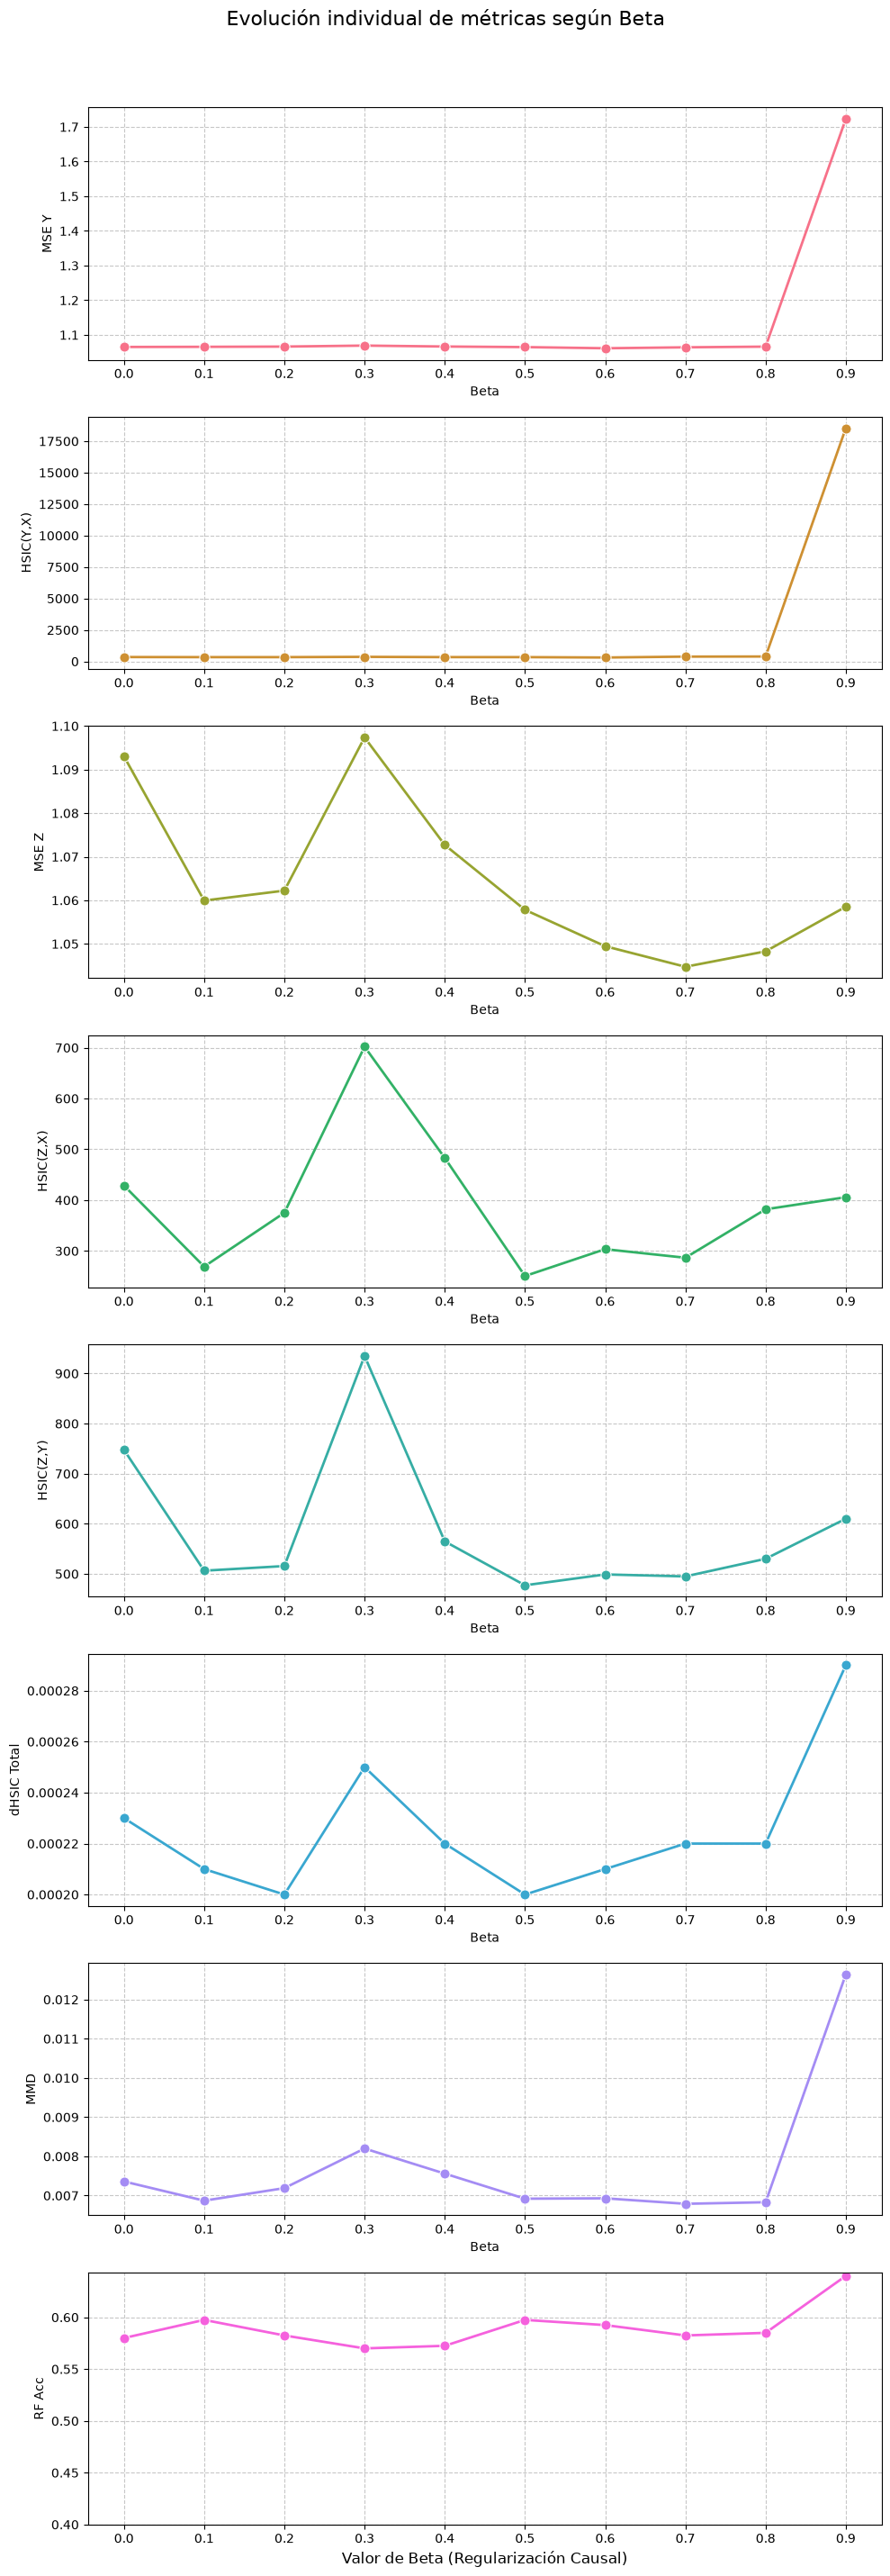

In [14]:
# ==============================================================================
# BLOQUE 4: VISUALIZACIÓN PERSONALIZADA DE MÉTRICAS
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_cada_metrica_individual_ajustado(df):
    # 1. FILTRADO: Excluimos el modelo 'HSIC' puro
    df_to_plot = df[df['Conf'] != 'HSIC'].copy()
    
    # 2. Definir métricas a graficar
    excluidas = ['Conf', 'Alpha', 'Beta']
    metricas = [c for c in df_to_plot.columns if c not in excluidas]
    
    # 3. Configurar colores distintos para cada métrica
    paleta = sns.color_palette("husl", len(metricas))
    
    # 4. Configurar la figura
    num_plots = len(metricas)
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 3.5 * num_plots), sharex=False)
    fig.suptitle('Evolución individual de métricas según Beta', fontsize=16, y=1.02)
    
    # Asegurar que axes sea iterable incluso si hay una sola gráfica
    if num_plots == 1: axes = [axes]
    
    # 5. Dibujar cada métrica
    for i, metrica in enumerate(metricas):
        ax = axes[i]
        sns.lineplot(data=df_to_plot, x='Beta', y=metrica, ax=ax, 
                     marker='o', color=paleta[i], linewidth=2, markersize=8)
        
        # AJUSTE ESPECÍFICO: RF Acc comienza en 0.4
        if 'RF Acc' in metrica:
            ax.set_ylim(bottom=0.4)
            
        # AJUSTE DE EJE X: Forzar que aparezcan todos los valores de Beta
        valores_beta = sorted(df_to_plot['Beta'].unique())
        ax.set_xticks(valores_beta)
        
        ax.set_ylabel(metrica, fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.xlabel("Valor de Beta (Regularización Causal)", fontsize=12)
    plt.tight_layout()
    plt.show()

# Ejecutar
plot_cada_metrica_individual_ajustado(df_final)